# Análisis empírico de rendimiento k6 — `cache_frio` vs `cache_caliente`

**Objetivo.** Evaluar empíricamente el impacto de Redis (caché de catálogo) sobre el **tiempo de respuesta** (`http_req_duration`, ms) y el **throughput** (RPS) del endpoint `GET /api/v1/libros`, comparando los escenarios `cache_frio` y `cache_caliente` de las 5 corridas reales de `make bench`.

**Por qué estadística no paramétrica.** Con solo **N = 5** corridas pareadas no se puede asumir normalidad de forma fiable. Por eso este cuaderno usa:

- **Wilcoxon de rangos con signo** (muestras pareadas) sobre el p95 de cada corrida.
- **Cliff's delta** como tamaño de efecto (la significancia sola no basta con n pequeño).

**Fuente de datos (verificada en `docs/mediciones/DATA-DICTIONARY.md`).** Archivos NDJSON reales:

`../docs/mediciones/perf/k6-run{1..5}.json` (relativo a `scripts/`)

Si algún archivo falta, el código **falla con un error explícito** — no genera mocks ni datos sintéticos.

**Alineación.** La lógica de agregación y el test pareado coinciden con `scripts/perf-analysis.py` y con el reporte `docs/mediciones/perf/REPORT.md`.

## 1. Dependencias y rutas a los archivos reales

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib

# matplotlib.use("Agg") NO se fija aqui (a diferencia de scripts/perf-analysis.py):
# rompe la captura inline de figuras cuando el cuaderno se ejecuta con nbconvert/Jupyter.
# El kernel de IPython ya usa su backend inline por defecto para capturar plt.show().
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")

# Paleta Okabe-Ito (misma que scripts/perf-analysis.py / informe)
COLOR_CALIENTE = "#E69F00"
COLOR_FRIO = "#56B4E9"
SCENARIOS = ("cache_caliente", "cache_frio")

# Ventana de carga por escenario (k6/opts.js): 10s ramp-up + 30s sostenido + 10s ramp-down
DURACION_VENTANA_S = 50.0

# Rutas relativas al cuaderno en scripts/: ../docs/mediciones/perf/k6-run{1..5}.json
# Ubicacion documentada en docs/mediciones/DATA-DICTIONARY.md
NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "perf-analysis.ipynb").exists() or NOTEBOOK_DIR.name == "scripts":
    PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "scripts" else NOTEBOOK_DIR.parent
    PERF_DIR = (NOTEBOOK_DIR / "../docs/mediciones/perf").resolve()
elif (NOTEBOOK_DIR / "docs" / "mediciones" / "perf").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR
    PERF_DIR = PROJECT_ROOT / "docs" / "mediciones" / "perf"
else:
    raise FileNotFoundError(
        f"No se pudo resolver docs/mediciones/perf desde CWD={NOTEBOOK_DIR}. "
        "Abre el cuaderno desde scripts/ o desde la raiz del repo."
    )

if NOTEBOOK_DIR.name == "scripts":
    PROJECT_ROOT = NOTEBOOK_DIR.parent

RUN_PATHS = [PERF_DIR / f"k6-run{i}.json" for i in range(1, 6)]

missing = [str(p) for p in RUN_PATHS if not p.is_file()]
if missing:
    raise FileNotFoundError(
        "Faltan archivos reales de k6 documentados en "
        "docs/mediciones/DATA-DICTIONARY.md "
        "(seccion docs/mediciones/perf/k6-run{1..5}.json). "
        f"No se inventan datos. Ausentes: {missing}. "
        f"CWD={NOTEBOOK_DIR}, PERF_DIR={PERF_DIR}"
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PERF_DIR (desde scripts/): ../docs/mediciones/perf")
print("Archivos k6 (NDJSON) encontrados:")
for p in RUN_PATHS:
    try:
        rel = p.relative_to(PROJECT_ROOT)
    except ValueError:
        rel = p
    print(f"  - {rel}  ({p.stat().st_size:,} bytes)")

PROJECT_ROOT: D:\UTEQ\5to semestre\appWeb\entrega 3\sgb-saas
PERF_DIR (desde scripts/): ../docs/mediciones/perf
Archivos k6 (NDJSON) encontrados:
  - docs\mediciones\perf\k6-run1.json  (15,178,815 bytes)
  - docs\mediciones\perf\k6-run2.json  (15,700,073 bytes)
  - docs\mediciones\perf\k6-run3.json  (15,715,336 bytes)
  - docs\mediciones\perf\k6-run4.json  (15,789,402 bytes)
  - docs\mediciones\perf\k6-run5.json  (15,694,875 bytes)


## 2. Carga de datos (pandas)

Cada `k6-runN.json` es **NDJSON** (un objeto JSON por línea). Solo se conservan líneas `type == "Point"` con métrica `http_req_duration` y tag `scenario` ∈ {`cache_caliente`, `cache_frio`}, según el diccionario de datos. Las peticiones de `::setup` (login) se excluyen porque no traen tag `scenario`.

In [2]:
def cargar_http_req_duration(paths: list[Path]) -> pd.DataFrame:
    """Lee las 5 corridas NDJSON reales y devuelve un DataFrame largo."""
    filas: list[dict] = []
    for run_idx, path in enumerate(paths, start=1):
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                if obj.get("type") != "Point":
                    continue
                if obj.get("metric") != "http_req_duration":
                    continue
                tags = obj.get("data", {}).get("tags") or {}
                escenario = tags.get("scenario")
                if escenario not in SCENARIOS:
                    continue
                filas.append(
                    {
                        "run": run_idx,
                        "escenario": escenario,
                        "duration_ms": float(obj["data"]["value"]),
                        "status": tags.get("status", "0"),
                        "time": obj["data"].get("time"),
                    }
                )
    if not filas:
        raise ValueError(
            "No se encontraron Points de http_req_duration con tag scenario. "
            "Revisa que los JSON sean salidas reales de k6 (--out json=)."
        )
    return pd.DataFrame(filas)


df = cargar_http_req_duration(RUN_PATHS)
df_frio = df.loc[df["escenario"] == "cache_frio"].copy()
df_caliente = df.loc[df["escenario"] == "cache_caliente"].copy()

print("Total peticiones medibles:", len(df))
print("df_frio:", len(df_frio), "| df_caliente:", len(df_caliente))
print("Corridas presentes:", sorted(df["run"].unique().tolist()))
df.head()

Total peticiones medibles: 20003
df_frio: 10074 | df_caliente: 9929
Corridas presentes: [1, 2, 3, 4, 5]


,run,escenario,duration_ms,status,time
0,1,cache_caliente,131.812384,200,2026-07-31T02:54:21.753009199Z
1,1,cache_caliente,330.960332,200,2026-07-31T02:54:21.753525946Z
2,1,cache_caliente,25.076578,200,2026-07-31T02:54:21.847063421Z
3,1,cache_caliente,30.819523,200,2026-07-31T02:54:22.052917121Z
4,1,cache_caliente,29.429332,200,2026-07-31T02:54:22.250659941Z


## 3. Estadística descriptiva (mediana, p90, p95)

Tabla comparativa sobre el **pool agregado** de las 5 corridas (misma agregación que reporta el informe en el Bloque de Resultados).

In [3]:
def resumen_latencia(series: pd.Series) -> dict:
    return {
        "n": int(series.shape[0]),
        "mediana_ms": float(series.median()),
        "p90_ms": float(series.quantile(0.90)),
        "p95_ms": float(series.quantile(0.95)),
    }


tabla_descriptiva = pd.DataFrame(
    [
        {"escenario": "cache_caliente", **resumen_latencia(df_caliente["duration_ms"])},
        {"escenario": "cache_frio", **resumen_latencia(df_frio["duration_ms"])},
    ]
).set_index("escenario")

tabla_descriptiva.round(2)

,n,mediana_ms,p90_ms,p95_ms
escenario,,,,
cache_caliente,9929,5.49,11.66,19.49
cache_frio,10074,4.34,6.70,7.50


## 4. Prueba de hipótesis — Wilcoxon pareado (p95 por corrida)

No se comparan pools independientes de peticiones (eso inflaría el n artificialmente). Se empareja el **p95 de cada una de las 5 corridas**: la posición *i* de `cache_caliente` y `cache_frio` corresponde a la misma sesión de `make bench`.

In [4]:
p95_por_run = (
    df.groupby(["run", "escenario"])["duration_ms"]
    .quantile(0.95)
    .unstack("escenario")
    .reindex(columns=list(SCENARIOS))
    .sort_index()
)

if p95_por_run.shape[0] != 5:
    raise ValueError(
        f"Se esperaban 5 corridas pareadas; hay {p95_por_run.shape[0]}: "
        f"{p95_por_run.index.tolist()}"
    )
if p95_por_run.isna().any().any():
    raise ValueError(
        "Hay corridas sin p95 en alguno de los escenarios; no se inventan valores. "
        f"Tabla:\n{p95_por_run}"
    )

print("p95 (ms) por corrida (pareado):")
print(p95_por_run.round(2))

x = p95_por_run["cache_caliente"].to_numpy()
y = p95_por_run["cache_frio"].to_numpy()

wilcoxon_result = stats.wilcoxon(x, y)
print("\nWilcoxon signed-rank (pareado, scipy.stats.wilcoxon)")
print(f"  estadístico W = {wilcoxon_result.statistic:.4f}")
print(f"  p-value       = {wilcoxon_result.pvalue:.6f}")
if wilcoxon_result.pvalue < 0.05:
    print("  Interpretación: diferencia estadísticamente significativa (p < 0.05).")
else:
    print(
        "  Interpretación: sin diferencia estadísticamente significativa (p >= 0.05). "
        "Con n=5 el p mínimo exacto de dos colas alcanzable con dirección perfectamente "
        "consistente es 0.0625 (ver docs/capitulos/08-resultados.tex)."
    )

p95 (ms) por corrida (pareado):
escenario  cache_caliente  cache_frio
run                                  
1                  107.31       10.96
2                   10.56        5.93
3                    6.26        5.73
4                    9.03        4.82
5                   12.36        6.69

Wilcoxon signed-rank (pareado, scipy.stats.wilcoxon)
  estadístico W = 0.0000
  p-value       = 0.062500
  Interpretación: sin diferencia estadísticamente significativa (p >= 0.05). Con n=5 el p mínimo exacto de dos colas alcanzable con dirección perfectamente consistente es 0.0625 (ver docs/capitulos/08-resultados.tex).


## 5. Tamaño de efecto — Cliff's delta

Cliff's delta ∈ [-1, 1]. Magnitud según Romano et al. (2006): despreciable (< 0.147), pequeño (< 0.33), mediano (< 0.474), grande (≥ 0.474). Signo negativo ⇒ `cache_caliente` tiende a valores más altos (más lento) que `cache_frio`.

In [5]:
def cliffs_delta(a, b) -> float:
    """δ = (#(a_i < b_j) - #(a_i > b_j)) / (n * m)."""
    a = list(a)
    b = list(b)
    n, m = len(a), len(b)
    if n == 0 or m == 0:
        raise ValueError("Cliff's delta requiere dos muestras no vacías.")
    mayor = menor = 0
    for ai in a:
        for bj in b:
            if ai > bj:
                mayor += 1
            elif ai < bj:
                menor += 1
    return (menor - mayor) / (n * m)


def interpretar_cliffs_delta(delta: float) -> str:
    d = abs(delta)
    if d < 0.147:
        return "despreciable"
    if d < 0.33:
        return "pequeño"
    if d < 0.474:
        return "mediano"
    return "grande"


delta = cliffs_delta(x, y)
mag = interpretar_cliffs_delta(delta)
print(f"Cliff's delta = {delta:.4f}  (efecto {mag})")
if delta < 0:
    tendencia = "cache_caliente tiende a ser MAS lento que cache_frio"
elif delta > 0:
    tendencia = "cache_frio tiende a ser MAS lento que cache_caliente"
else:
    tendencia = "sin tendencia de dominancia"
print(f"Tendencia: {tendencia}")

Cliff's delta = -0.6800  (efecto grande)
Tendencia: cache_caliente tiende a ser MAS lento que cache_frio


## 6. Visualizaciones

### 6.1 Boxplot comparativo de latencias

Distribución de `http_req_duration` (ms) por escenario sobre el pool de las 5 corridas.

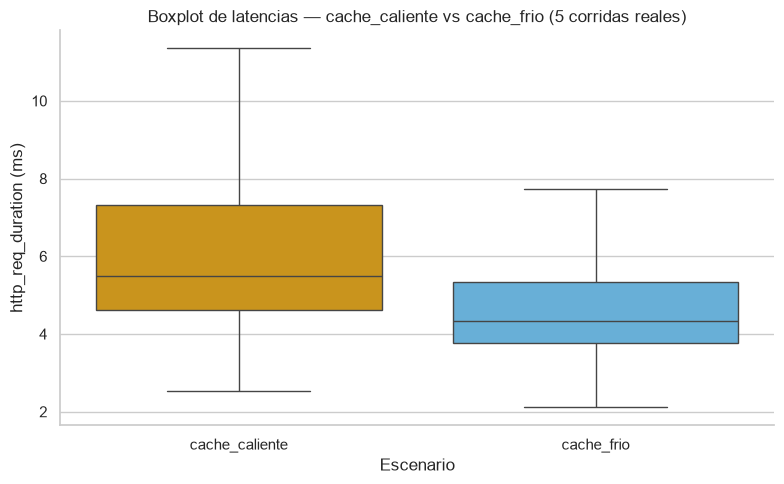

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="escenario",
    y="duration_ms",
    order=list(SCENARIOS),
    hue="escenario",
    palette={"cache_caliente": COLOR_CALIENTE, "cache_frio": COLOR_FRIO},
    legend=False,
    showfliers=False,
    ax=ax,
)
ax.set_ylabel("http_req_duration (ms)")
ax.set_xlabel("Escenario")
ax.set_title("Boxplot de latencias — cache_caliente vs cache_frio (5 corridas reales)")
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### 6.2 Throughput (RPS) por corrida

RPS ≈ nº de peticiones medibles del escenario / 50 s (ventana documentada en `k6/opts.js` y usada por `scripts/perf-analysis.py`).

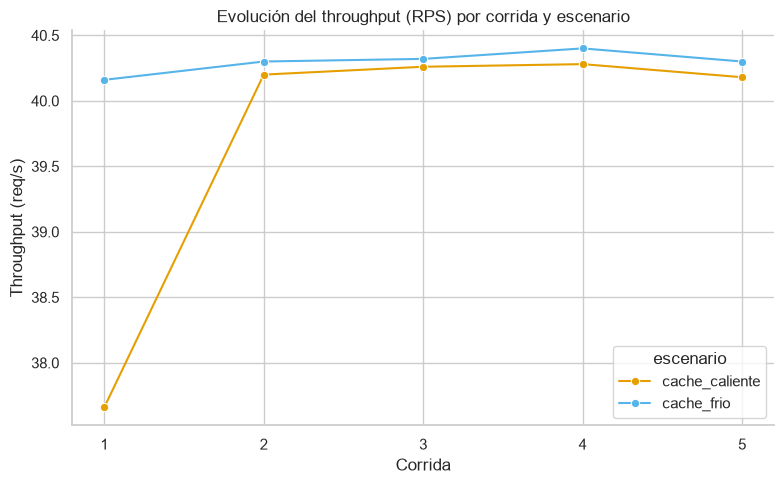

escenario,cache_caliente,cache_frio
run,,
1,37.66,40.16
2,40.20,40.30
3,40.26,40.32
4,40.28,40.40
5,40.18,40.30


In [7]:
throughput = (
    df.groupby(["run", "escenario"])
    .size()
    .rename("n_requests")
    .reset_index()
)
throughput["rps"] = throughput["n_requests"] / DURACION_VENTANA_S

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=throughput,
    x="run",
    y="rps",
    hue="escenario",
    hue_order=list(SCENARIOS),
    palette={"cache_caliente": COLOR_CALIENTE, "cache_frio": COLOR_FRIO},
    marker="o",
    ax=ax,
)
ax.set_xticks(sorted(throughput["run"].unique()))
ax.set_xlabel("Corrida")
ax.set_ylabel("Throughput (req/s)")
ax.set_title("Evolución del throughput (RPS) por corrida y escenario")
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

throughput.pivot(index="run", columns="escenario", values="rps").round(2)

## 7. Lectura breve de resultados

Este cuaderno **no inventa cifras**: relee los NDJSON versionados. La interpretación metodológica completa (incluido el hallazgo de que `cache_frio` puede medir sobre todo páginas vacías por construcción del PRNG) está en `docs/mediciones/perf/REPORT.md` y en `docs/capitulos/08-resultados.tex`. Aquí el entregable es el pipeline reproducible: carga → descriptivos → Wilcoxon → Cliff's delta → gráficos.